# Data Quality Analysis — session warnings audit

Audits `tracking_sessions_v2` for per-session `metadata.warnings`, broken down by
client and warning type, with an `early_stop` -> `last_delivery` reclassification
for sessions whose last path point lands within `LAST_DELIVERY_WINDOW_S` of the
session timestamp.

**How to use:** run the setup cells once, top to bottom
(imports -> config -> helpers -> `audit_warnings`). Then use the **Run audit**
cell at the bottom and re-run it with different `client` / `days` / `offset_days`.

Requires env vars `MONGO_MAIN_URI` and `MONGO_MAIN_DB`.

In [13]:
MONGO_URL = "mongodb://10.3.32.15:27017/"
MONGO_MAIN_DB='main'

In [14]:
import os
import time
from threading import Thread
from datetime import datetime, timedelta, timezone
from difflib import get_close_matches

from bson import ObjectId
from pymongo import MongoClient
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt


# theme
BG, TEXT, MUTED = "#EAEAEA", "#2F2F2F", "#4A4A4A"
ORANGE, GREEN, PURPLE = "#F5A229", "#198A1B", "#5E3FB3"

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 10.5,
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "savefig.dpi": 180,
    "text.color": TEXT, "axes.labelcolor": TEXT, "axes.titlecolor": TEXT,
    "xtick.color": TEXT, "ytick.color": TEXT,
})

In [15]:
CLIENT_NAMES = {
    "69969e8f2a98677d93b18e4c": "Dispatch",
    "69703f3eb8b8d26bc81157c5": "GoPuff",
    "68011a5afadb01600e7226a8": "Vamo",
    "690bf25375abb0f944328b6a": "DoorDash",
    "695d4e21275acb5359d63814": "Jitsu",
    "69e0f322d50a54cfffd922ab": "Quiver",
    "6a074e9379d934da6e23f90b": "CXT",
}

LAST_DELIVERY_WINDOW_S = 30

## Helpers

Client name/id resolution, a threaded progress spinner for long queries, and the horizontal-bar plotting primitive.

In [16]:
def _resolve_client(client):
    if client is None or str(client).strip().upper() == "ALL":
        return None, "All clients"

    client = str(client).strip()

    if client in CLIENT_NAMES:
        return client, CLIENT_NAMES[client]

    name_to_id = {v.lower(): k for k, v in CLIENT_NAMES.items()}
    cl = client.lower()

    if cl in name_to_id:
        cid = name_to_id[cl]
        return cid, CLIENT_NAMES[cid]

    matches = get_close_matches(cl, list(name_to_id.keys()), n=1, cutoff=0.5)
    if matches:
        cid = name_to_id[matches[0]]
        print(f":warning: '{client}' not found — using closest match: {CLIENT_NAMES[cid]}")
        return cid, CLIENT_NAMES[cid]

    if len(client) == 24:
        return client, client[:8]

    raise ValueError(
        f"Could not resolve '{client}'. Known clients: {list(CLIENT_NAMES.values())}"
    )

In [17]:
def _run_with_progress(label, fn):
    result, error = [None], [None]

    def runner():
        try:
            result[0] = fn()
        except Exception as e:
            error[0] = e

    t = Thread(target=runner, daemon=True)
    t.start()

    with tqdm(desc=label, bar_format="{desc}  :stopwatch: {elapsed}") as pbar:
        while t.is_alive():
            time.sleep(0.2)
            pbar.refresh()
    t.join()

    if error[0]:
        raise error[0]
    return result[0]

In [18]:
def _hbar(ax, labels, values, title, colors, value_labels=None):
    ax.set_facecolor(BG)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_xticks([])
    if not labels:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", color=MUTED)
        return
    colors = [colors] * len(labels) if isinstance(colors, str) else colors
    y = np.arange(len(labels))
    maxv = max(values) if values else 1
    ax.barh(y, values, height=0.72, color=colors, edgecolor="none")
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=10.5)
    ax.tick_params(axis="y", left=False, labelleft=True, pad=4)
    ax.tick_params(axis="x", bottom=False)
    if value_labels is None:
        value_labels = [f"{v*100:.1f}%" for v in values]
    for yi, v, lbl in zip(y, values, value_labels):
        ax.text(v + maxv * 0.01, yi, lbl, ha="left", va="center",
                fontsize=10.5, color=MUTED)
    ax.set_xlim(0, maxv * 1.25 if maxv else 1)
    ax.set_ylim(-0.6, len(labels) - 0.4)
    ax.invert_yaxis()
    ax.set_title(title, loc="left", pad=8, fontsize=12)

## Query

`build_pipeline` constructs the aggregation (match window + `early_stop` reclassification + facets). `run_audit` runs it and returns the raw, parsed result so you can re-plot without re-querying.

In [19]:
def build_pipeline(match, is_all):
    facets = {
        "totals": [{"$count": "n"}],
        "with_field": [
            {"$match": {"w": {"$exists": True}}},
            {"$count": "n"},
        ],
        "with_issue": [
            {"$match": {"w.0": {"$exists": True}}},
            {"$count": "n"},
        ],
        "by_type": [
            {"$match": {"w": {"$exists": True}}},
            {"$unwind": "$w"},
            {"$group": {
                "_id": {"$toUpper": "$w.type"},
                "count": {"$sum": 1},
                "samples": {"$push": "$uuid"},
            }},
            {"$project": {"count": 1, "samples": {"$slice": ["$samples", 20]}}},
            {"$sort": {"count": -1}},
        ],
    }

    if is_all:
        facets["by_client"] = [
            {"$match": {"w": {"$exists": True}}},
            {"$group": {
                "_id": "$c",
                "total": {"$sum": 1},
                "with_issue": {"$sum": {"$cond": [{"$gt": [{"$size": "$w"}, 0]}, 1, 0]}},
            }},
            {"$sort": {"with_issue": -1}},
        ]

    return [
        {"$match": match},
        {"$project": {
            "_id": 0,
            "uuid": 1,
            "c": "$clientID",
            "ts": "$timestamp",
            "w": "$metadata.warnings",
            "last_path_ts": {
                "$let": {
                    "vars": {
                        "path_entry": {
                            "$arrayElemAt": [
                                {"$filter": {
                                    "input": {"$ifNull": ["$debug", []]},
                                    "as": "d",
                                    "cond": {"$eq": ["$$d.type", "path"]},
                                }},
                                0,
                            ]
                        }
                    },
                    "in": {"$arrayElemAt": ["$$path_entry.data.timestamp", -1]},
                }
            },
        }},
        {"$addFields": {
            "is_last_delivery": {
                "$let": {
                    "vars": {"diff": {"$subtract": [
                        {"$ifNull": ["$last_path_ts", -1e18]},
                        {"$ifNull": ["$ts", 1e18]},
                    ]}},
                    "in": {"$and": [
                        {"$gte": ["$$diff", 0]},
                        {"$lte": ["$$diff", LAST_DELIVERY_WINDOW_S]},
                    ]},
                }
            }
        }},
        {"$addFields": {
            "w": {
                "$map": {
                    "input": {"$ifNull": ["$w", []]},
                    "as": "warn",
                    "in": {
                        "$cond": [
                            {"$and": [
                                {"$eq": [{"$toLower": "$$warn.type"}, "early_stop"]},
                                "$is_last_delivery",
                            ]},
                            {"$mergeObjects": ["$$warn", {"type": "last_delivery"}]},
                            "$$warn",
                        ]
                    },
                }
            }
        }},
        {"$facet": facets},
    ]

In [28]:
def run_audit(client=None, days=21, offset_days=0):
    """Query tracking_sessions_v2 and return the parsed audit result (no plotting)."""
    uri = MONGO_URL
    dbn = MONGO_MAIN_DB
    col = MongoClient(uri)[dbn]["tracking_sessions_v2"]

    client_id, client_name = _resolve_client(client)
    is_all = client_id is None

    now = datetime.now(timezone.utc)
    end = now - timedelta(days=offset_days)
    start = end - timedelta(days=days)
    min_oid = ObjectId.from_datetime(start)
    max_oid = ObjectId.from_datetime(end)

    match = {
        "_id": {"$gte": min_oid, "$lt": max_oid},
        "uuid": {"$exists": True, "$ne": None},
    }
    if not is_all:
        match["clientID"] = client_id

    pipeline = build_pipeline(match, is_all)

    label = f"Querying {client_name} ({start:%m-%d} → {end:%m-%d})"
    res = _run_with_progress(
        label,
        lambda: next(col.aggregate(pipeline, allowDiskUse=True, hint={"_id": 1})),
    )

    total = res["totals"][0]["n"] if res["totals"] else 0
    with_field = res["with_field"][0]["n"] if res["with_field"] else 0
    with_issue = res["with_issue"][0]["n"] if res["with_issue"] else 0

    return {
        "total": total,
        "with_field": with_field,
        "with_issue": with_issue,
        "excluded": total - with_field,
        "by_type": res["by_type"],
        "by_client": res.get("by_client", []),
        "range": (start, end),
        "is_all": is_all,
        "client_name": client_name,
    }

## Render

Prints the summary and draws the overview / by-client / by-type charts from a `run_audit` result.

In [29]:
def render_audit(r):
    if r is None:
        return None

    total = r["total"]
    with_field = r["with_field"]
    with_issue = r["with_issue"]
    excluded = r["excluded"]
    by_type = r["by_type"]
    by_client = r["by_client"]
    is_all = r["is_all"]
    client_name = r["client_name"]
    start, end = r["range"]

    range_label = f"{start:%Y-%m-%d} → {end:%Y-%m-%d}"
    suffix = f" — {client_name}"

    if total == 0:
        print(f"No sessions found for {client_name} ({range_label}).")
        return r

    print(f"\n{client_name} ({range_label})")
    print(f"  total sessions:         {total}")
    print(f"  with warnings field:    {with_field}")
    print(f"  excluded (no field):    {excluded}")
    print(f"  with ≥1 warning:        {with_issue}")

    if with_field == 0:
        print(f"\nNo sessions in this window have the warnings field. Nothing to plot.")
        return r

    fig, ax = plt.subplots(figsize=(7.5, 3.2))
    _hbar(
        ax,
        ["Clean", "Has issue"],
        [(with_field - with_issue) / with_field, with_issue / with_field],
        f"Audit overview{suffix}  (n={with_field}, {range_label})",
        [GREEN, ORANGE],
    )
    plt.tight_layout(); plt.show()

    if is_all and by_client and with_issue > 0:
        rows = []
        for row in by_client:
            cid = row["_id"]
            cname = CLIENT_NAMES.get(cid, cid[:8] if cid else "UNKNOWN")
            rows.append({
                "name": cname,
                "total": row["total"],
                "issues": row["with_issue"],
                "share": row["with_issue"] / with_issue,
                "rate": row["with_issue"] / row["total"] if row["total"] else 0,
            })
        rows = [row for row in rows if row["issues"] > 0]
        rows.sort(key=lambda x: x["issues"], reverse=True)

        labels = [row["name"] for row in rows]
        values = [row["issues"] for row in rows]
        vlabels = [f"{row['issues']:,} / {row['total']:,}  ({row['share']*100:.1f}% of issues, {row['rate']*100:.1f}% rate)"
                   for row in rows]

        fig, ax = plt.subplots(figsize=(11, max(3.0, len(labels) * 0.55)))
        _hbar(
            ax, labels, values,
            f"Issue contribution by client  (total {with_issue:,} sessions w/ issues, {range_label})",
            PURPLE, value_labels=vlabels,
        )
        plt.tight_layout(); plt.show()

        print(f"\n{'─'*60}\n  Issue contribution by client  ({range_label})\n{'─'*60}")
        for row in rows:
            print(f"  {row['name']:<14} {row['issues']:>6,} / {row['total']:>6,} sessions  "
                  f"→  {row['share']*100:>5.1f}% of issues  |  {row['rate']*100:>5.1f}% client rate")

    if by_type:
        labels = [t["_id"] or "UNKNOWN" for t in by_type]
        values = [t["count"] / with_field for t in by_type]
        fig, ax = plt.subplots(figsize=(10, max(3.0, len(labels) * 0.5)))
        _hbar(
            ax, labels, values,
            f"Issue distribution{suffix}  (% of {with_field} sessions, {range_label})",
            ORANGE,
        )
        plt.tight_layout(); plt.show()

        pct = with_issue / with_field * 100
        print(f"\n{'─'*60}\n  Issue distribution{suffix}  ({range_label})"
              f"\n  {with_issue} / {with_field} sessions had warnings ({pct:.1f}%)"
              f"\n  ({excluded} sessions excluded — no warnings field)"
              f"\n{'─'*60}")
        for t in by_type:
            tag = t["_id"] or "UNKNOWN"
            tag_pct = t["count"] / with_field * 100
            print(f"\n  {tag}  (n={t['count']}, {tag_pct:.1f}%)")
            for u in t["samples"]:
                print(f"    {u}")

    return r

In [30]:
def audit_warnings(client=None, days=21, offset_days=0):
    """Query + render in one call (kept for convenience)."""
    return render_audit(run_audit(client, days=days, offset_days=offset_days))

## Run audit

Tweak `client` (name, id, or `"ALL"`), `days`, and `offset_days` and re-run.
Use `r = run_audit(...)` then `render_audit(r)` if you want the raw result to poke at.

Querying CXT (06-11 → 06-18)  :stopwatch: 00:03



CXT (2026-06-11 → 2026-06-18)
  total sessions:         377
  with warnings field:    377
  excluded (no field):    0
  with ≥1 warning:        276


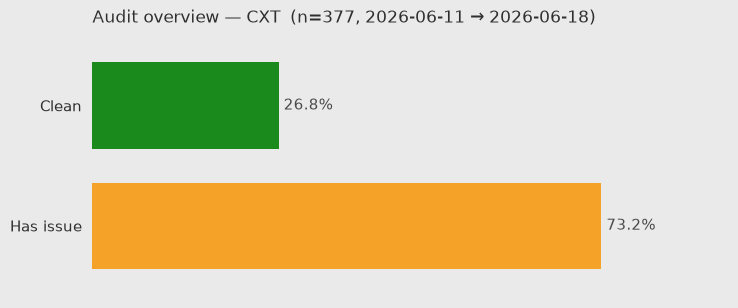

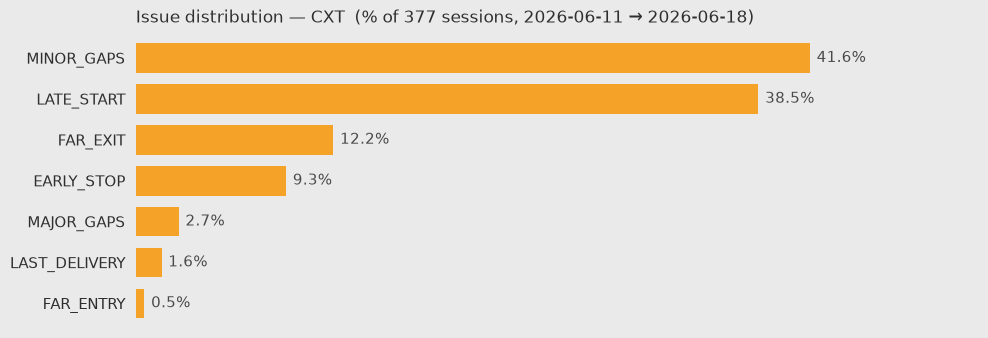


────────────────────────────────────────────────────────────
  Issue distribution — CXT  (2026-06-11 → 2026-06-18)
  276 / 377 sessions had warnings (73.2%)
  (0 sessions excluded — no warnings field)
────────────────────────────────────────────────────────────

  MINOR_GAPS  (n=157, 41.6%)
    0731a57e-3fc9-46d9-b82f-0997a22fdc92
    031aa243-77ab-4ecc-b6ff-de0f9b909615
    9ed342ac-3cac-4edb-ba06-53836ef85320
    6b424e5c-001d-4414-9cf5-63af85fc0cf5
    e2de213f-8b85-4194-88fd-7003ce9f2747
    73c7860a-d0f8-40ee-abe7-683f165f546f
    b3ac1650-cd6b-4801-8d7f-d4f96610cf8b
    3df7823b-8ba1-470e-8dab-bbf53520b648
    e5000ce7-279c-4859-bd3c-a5f49ef2cef2
    56453ed3-ee3b-4647-93a7-5cede72fd01f
    29ab72d2-621f-454e-93c8-6db10c498d15
    6407d643-86d2-4fe0-a4bc-8f6f98ee8b59
    d48bb912-f3a7-4591-a84d-7a21cfc91dbe
    d5f8c822-a7b6-4745-978b-919a746b797f
    aa1bccdf-b218-4f66-a031-5af601965c88
    e4267fbc-b670-4f64-b7ab-a5b3f8463097
    ae246551-0b70-4f39-a538-3ad9125a435a
    99609e

{'total': 377,
 'with_field': 377,
 'with_issue': 276,
 'excluded': 0,
 'by_type': [{'_id': 'MINOR_GAPS',
   'count': 157,
   'samples': ['0731a57e-3fc9-46d9-b82f-0997a22fdc92',
    '031aa243-77ab-4ecc-b6ff-de0f9b909615',
    '9ed342ac-3cac-4edb-ba06-53836ef85320',
    '6b424e5c-001d-4414-9cf5-63af85fc0cf5',
    'e2de213f-8b85-4194-88fd-7003ce9f2747',
    '73c7860a-d0f8-40ee-abe7-683f165f546f',
    'b3ac1650-cd6b-4801-8d7f-d4f96610cf8b',
    '3df7823b-8ba1-470e-8dab-bbf53520b648',
    'e5000ce7-279c-4859-bd3c-a5f49ef2cef2',
    '56453ed3-ee3b-4647-93a7-5cede72fd01f',
    '29ab72d2-621f-454e-93c8-6db10c498d15',
    '6407d643-86d2-4fe0-a4bc-8f6f98ee8b59',
    'd48bb912-f3a7-4591-a84d-7a21cfc91dbe',
    'd5f8c822-a7b6-4745-978b-919a746b797f',
    'aa1bccdf-b218-4f66-a031-5af601965c88',
    'e4267fbc-b670-4f64-b7ab-a5b3f8463097',
    'ae246551-0b70-4f39-a538-3ad9125a435a',
    '99609e44-afa6-47ae-a6e1-4aad5a6c812d',
    '6f4785d8-39ad-41c7-bf8e-cc41a897c0ec',
    '8aecd754-d9de-49a7-b692-1

In [31]:
audit_warnings("CXT", days=7)